# 🏋️ Arm Raise Rehabilitation Analysis with MediaPipe Tasks

In this notebook, I analyse **arm raise rehabilitation exercises** from video.

I am using a small subset of the **WLU Rehabilitation Posture** dataset:

- 5 videos from **Arm Raise Correct**
- 5 videos from **Arm Raise Incorrect**

I built this as a movement-analysis project, not as a generic pose demo.

## Why I built this project

What interests me about Prof. Ricca’s lab is not VR as visual spectacle. It is the harder question underneath it:

**How do I measure what the learner or patient actually did?**

That matters in rehabilitation and technical gesture training because showing an exercise is not enough. The system also needs a way to measure:

- whether the movement was completed properly
- whether the range was sufficient
- whether the motion was smooth or unstable
- whether a correct and incorrect pattern can be distinguished

This notebook is my first step toward that kind of behavioural analysis layer.

## What this project does

Using arm raise videos, I:

1. detect body landmarks with **MediaPipe Tasks Pose Landmarker**
2. extract upper-limb points such as shoulder, elbow, wrist, and hip
3. compute angle-based movement signals over time
4. compare correct vs incorrect arm raises
5. estimate simple metrics such as:
   - shoulder angle curve
   - elbow angle curve
   - wrist trajectory
   - repetition structure
   - movement range
   - path length

## Why I think this is useful

I see this as a lightweight behavioural analysis layer for rehabilitation and immersive training systems.

I am not presenting it as a finished clinical tool. I am presenting it as a first vision-based pipeline that could support:

- adaptive feedback
- movement monitoring
- comparison across training conditions
- low-cost motion analysis before richer motion capture

In [32]:
from pathlib import Path
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

## Step 1: Set the project paths

I am matching this notebook to my real folder structure.

The dataset sits inside:

- `data/wlu-rehabilitation-posture/Blurred/Arm Raise Correct`
- `data/wlu-rehabilitation-posture/Blurred/Arm Raise Incorrect`

The notebook will save outputs into:
- `outputs/frames`
- `outputs/plots`
- `outputs/csv`
- `outputs/videos`

I also create a `models` folder, because the Tasks API needs a `.task` model file.

In [33]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "wlu-rehabilitation-posture" / "Blurred"
CORRECT_DIR = DATA_DIR / "Arm Raise Correct"
INCORRECT_DIR = DATA_DIR / "Arm Raise Incorrect"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FRAMES_DIR = OUTPUTS_DIR / "frames"
PLOTS_DIR = OUTPUTS_DIR / "plots"
CSV_DIR = OUTPUTS_DIR / "csv"
VIDEOS_DIR = OUTPUTS_DIR / "videos"

MODEL_DIR = PROJECT_ROOT / "models"
POSE_MODEL_PATH = MODEL_DIR / "pose_landmarker.task"

for folder in [FRAMES_DIR, PLOTS_DIR, CSV_DIR, VIDEOS_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Correct dir exists:", CORRECT_DIR.exists())
print("Incorrect dir exists:", INCORRECT_DIR.exists())
print("Model path:", POSE_MODEL_PATH)

Project root: c:\Users\nosai\Downloads\rehab-pose-analysis
Correct dir exists: True
Incorrect dir exists: True
Model path: c:\Users\nosai\Downloads\rehab-pose-analysis\models\pose_landmarker.task


## Step 2: Download the Pose Landmarker model if it is missing

The MediaPipe Tasks API needs a pose model file.

This cell downloads it once into the local `models/` folder if it is not already there.

In [34]:
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task"

if not POSE_MODEL_PATH.exists():
    print("Downloading pose model...")
    urllib.request.urlretrieve(MODEL_URL, POSE_MODEL_PATH)
    print("Model downloaded to:", POSE_MODEL_PATH)
else:
    print("Model already exists:", POSE_MODEL_PATH)

Model already exists: c:\Users\nosai\Downloads\rehab-pose-analysis\models\pose_landmarker.task


## Step 3: Load the 10 selected videos

I am only using 5 correct and 5 incorrect videos.

That is enough for a first serious notebook.

In [35]:
correct_videos = sorted(CORRECT_DIR.glob("*.mp4"))[:5]
incorrect_videos = sorted(INCORRECT_DIR.glob("*.mp4"))[:5]

print("Correct videos found:", len(correct_videos))
for v in correct_videos:
    print("-", v.name)

print("\nIncorrect videos found:", len(incorrect_videos))
for v in incorrect_videos:
    print("-", v.name)

assert len(correct_videos) > 0, "No correct videos found."
assert len(incorrect_videos) > 0, "No incorrect videos found."

Correct videos found: 5
- 11.mp4
- 110.mp4
- 111.mp4
- 112.mp4
- 113.mp4

Incorrect videos found: 5
- 01.mp4
- 010.mp4
- 011.mp4
- 012.mp4
- 013.mp4


## Step 4: What the Tasks API is doing

I am using the newer **MediaPipe Tasks** API instead of the older `mp.solutions.pose` API.

This task predicts body landmarks from RGB frames.

I am using it because:
- it is the supported path now
- it works for images and video
- it gives me the landmark coordinates I need for movement analysis

base_options = python.BaseOptions(model_asset_path=str(POSE_MODEL_PATH))

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False
)

landmarker = vision.PoseLandmarker.create_from_options(options)
print("Pose Landmarker loaded successfully")

## Step 5: Inspect one sample video

Before I analyse movement, I inspect one sample video:
- frame count
- frame rate
- width
- height

In [36]:
sample_video_path = correct_videos[0]
print("Using sample video:", sample_video_path.name)

def inspect_video(video_path):
    cap = cv2.VideoCapture(str(video_path))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return frame_count, fps, width, height

frame_count, fps, width, height = inspect_video(sample_video_path)

print("Frame count:", frame_count)
print("FPS:", fps)
print("Width:", width)
print("Height:", height)

Using sample video: 11.mp4
Frame count: 184
FPS: 30.0
Width: 1280
Height: 720


## Step 6: Define drawing helpers

The Tasks API gives the landmarks, but I draw them myself so I can inspect the results clearly.

I only need simple point and connection drawing.

In [37]:
POSE_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 7),
    (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (15, 17), (15, 19), (15, 21),
    (16, 18), (16, 20), (16, 22),
    (11, 23), (12, 24),
    (23, 24),
    (23, 25), (25, 27), (27, 29), (29, 31),
    (24, 26), (26, 28), (28, 30), (30, 32)
]

def to_pixel(x_norm, y_norm, w, h):
    x = min(max(x_norm, 0.0), 1.0)
    y = min(max(y_norm, 0.0), 1.0)
    return int(x * w), int(y * h)

def draw_pose_landmarks_tasks(image_bgr, pose_landmarks_list):
    annotated = image_bgr.copy()
    h, w = annotated.shape[:2]

    for pose_landmarks in pose_landmarks_list:
        pts = [to_pixel(lm.x, lm.y, w, h) for lm in pose_landmarks]

        for a, b in POSE_CONNECTIONS:
            if a < len(pts) and b < len(pts):
                cv2.line(annotated, pts[a], pts[b], (0, 255, 0), 2)

        for (x, y) in pts:
            cv2.circle(annotated, (x, y), 3, (0, 0, 255), -1)

    return annotated

## Step 7: Process a video frame by frame

For each frame, I:
1. read it with OpenCV
2. convert it to RGB
3. wrap it as a MediaPipe image
4. run Pose Landmarker in video mode
5. draw landmarks for inspection
6. save the landmark coordinates into a dataframe

That dataframe becomes the real data source for the rest of the notebook.

In [38]:
def process_video_with_tasks(video_path, label_name, draw_landmarks=True, max_frames=150):
    cap = cv2.VideoCapture(str(video_path))
    rows = []
    processed_frames = []
    frame_idx = 0

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30.0

    while True:
        success, frame = cap.read()
        if not success:
            break

        if max_frames is not None and frame_idx >= max_frames:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

        timestamp_ms = int((frame_idx / fps) * 1000)
        result = landmarker.detect_for_video(mp_image, timestamp_ms)

        h, w, _ = frame.shape

        if result.pose_landmarks:
            if draw_landmarks:
                frame = draw_pose_landmarks_tasks(frame, result.pose_landmarks)

            for pose_id, pose_landmarks in enumerate(result.pose_landmarks):
                for landmark_id, lm in enumerate(pose_landmarks):
                    cx, cy = to_pixel(lm.x, lm.y, w, h)

                    rows.append({
                        "video_name": video_path.name,
                        "label": label_name,
                        "frame": frame_idx,
                        "pose_id": pose_id,
                        "landmark_id": landmark_id,
                        "x_norm": lm.x,
                        "y_norm": lm.y,
                        "z_norm": lm.z,
                        "visibility": getattr(lm, "visibility", np.nan),
                        "x_px": cx,
                        "y_px": cy
                    })

        processed_frames.append(frame.copy())
        frame_idx += 1

    cap.release()
    return pd.DataFrame(rows), processed_frames

sample_df, sample_frames = process_video_with_tasks(
    sample_video_path,
    label_name="correct",
    draw_landmarks=True,
    max_frames=150
)

print("Rows in landmark table:", len(sample_df))
display(sample_df.head())

## Step 8: Show a few annotated frames

I do this because I do not trust the movement features unless I trust the landmarks visually.

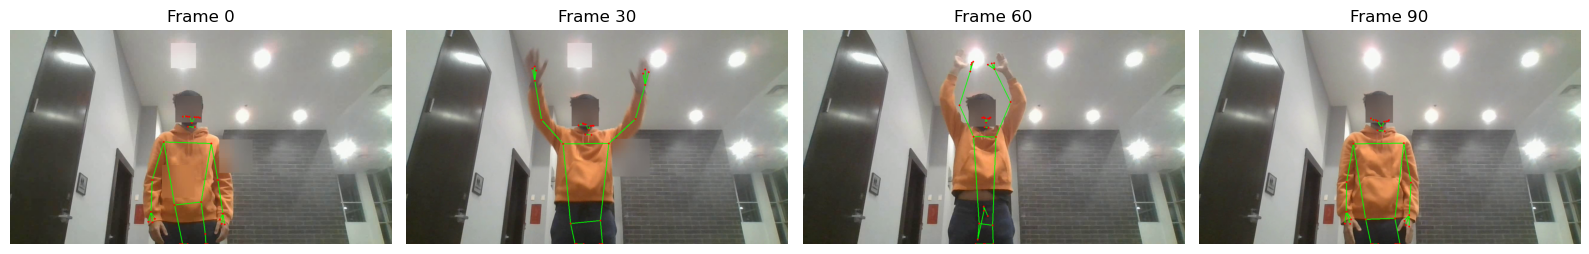

In [39]:
def show_selected_frames(frames, indices):
    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        if idx < len(frames):
            ax.imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))
            ax.set_title(f"Frame {idx}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_selected_frames(sample_frames, [0, 30, 60, 90])

## Step 9: Save a few proof frames


In [40]:
def save_selected_frames(frames, indices, prefix):
    saved_paths = []
    for idx in indices:
        if idx < len(frames):
            out_path = FRAMES_DIR / f"{prefix}_frame_{idx}.jpg"
            cv2.imwrite(str(out_path), frames[idx])
            saved_paths.append(out_path)
    return saved_paths

saved_paths = save_selected_frames(sample_frames, [0, 30, 60, 90], "sample_correct")
for p in saved_paths:
    print("Saved:", p)

Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\frames\sample_correct_frame_0.jpg
Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\frames\sample_correct_frame_30.jpg
Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\frames\sample_correct_frame_60.jpg
Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\frames\sample_correct_frame_90.jpg


## Step 10: Landmark helper functions

For arm raise analysis, I care most about:
- shoulder
- elbow
- wrist
- hip

These helpers make later calculations easier.

In [41]:
def get_landmark_xy(df, frame_number, landmark_id):
    row = df[(df["frame"] == frame_number) & (df["landmark_id"] == landmark_id)]
    if len(row) == 0:
        return None
    return int(row.iloc[0]["x_px"]), int(row.iloc[0]["y_px"])

def calculate_angle(p1, p2, p3):
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3

    angle = math.degrees(
        math.atan2(y3 - y2, x3 - x2) -
        math.atan2(y1 - y2, x1 - x2)
    )

    if angle < 0:
        angle += 360

    return angle

## Step 11: Elbow angle over time

I use:
- shoulder
- elbow
- wrist

This helps me see whether the arm stays extended or bends too much during the raise.

In [42]:
def compute_elbow_angle_series(df, side="right"):
    if side == "right":
        shoulder_id, elbow_id, wrist_id = 12, 14, 16
    else:
        shoulder_id, elbow_id, wrist_id = 11, 13, 15

    rows = []
    for f in sorted(df["frame"].unique()):
        p1 = get_landmark_xy(df, f, shoulder_id)
        p2 = get_landmark_xy(df, f, elbow_id)
        p3 = get_landmark_xy(df, f, wrist_id)

        if p1 and p2 and p3:
            rows.append({
                "frame": f,
                "elbow_angle_deg": calculate_angle(p1, p2, p3)
            })

    return pd.DataFrame(rows)

sample_elbow_df = compute_elbow_angle_series(sample_df, side="right")
display(sample_elbow_df.head())

,frame,elbow_angle_deg
0,0,165.069880
1,1,163.551827
2,2,161.537639
3,3,161.156775
4,4,162.081215


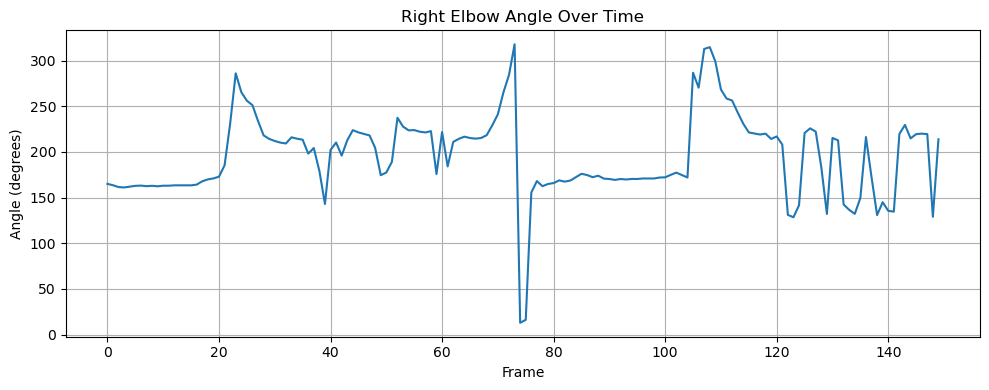

Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\plots\sample_right_elbow_angle.png


In [43]:
plt.figure(figsize=(10, 4))
plt.plot(sample_elbow_df["frame"], sample_elbow_df["elbow_angle_deg"])
plt.title("Right Elbow Angle Over Time")
plt.xlabel("Frame")
plt.ylabel("Angle (degrees)")
plt.grid(True)
plt.tight_layout()

elbow_plot_path = PLOTS_DIR / "sample_right_elbow_angle.png"
plt.savefig(elbow_plot_path, dpi=150)
plt.show()

print("Saved:", elbow_plot_path)

## Step 12: Shoulder angle over time

For arm raise, shoulder movement matters even more.

I use:
- hip
- shoulder
- elbow

This gives me a practical proxy for how much the arm lifts through the movement.

In [44]:
def compute_shoulder_angle_series(df, side="right"):
    if side == "right":
        hip_id, shoulder_id, elbow_id = 24, 12, 14
    else:
        hip_id, shoulder_id, elbow_id = 23, 11, 13

    rows = []
    for f in sorted(df["frame"].unique()):
        p1 = get_landmark_xy(df, f, hip_id)
        p2 = get_landmark_xy(df, f, shoulder_id)
        p3 = get_landmark_xy(df, f, elbow_id)

        if p1 and p2 and p3:
            rows.append({
                "frame": f,
                "shoulder_angle_deg": calculate_angle(p1, p2, p3)
            })

    return pd.DataFrame(rows)

sample_shoulder_df = compute_shoulder_angle_series(sample_df, side="right")
display(sample_shoulder_df.head())

,frame,shoulder_angle_deg
0,0,26.753372
1,1,27.228764
2,2,27.418985
3,3,26.786697
4,4,26.443016


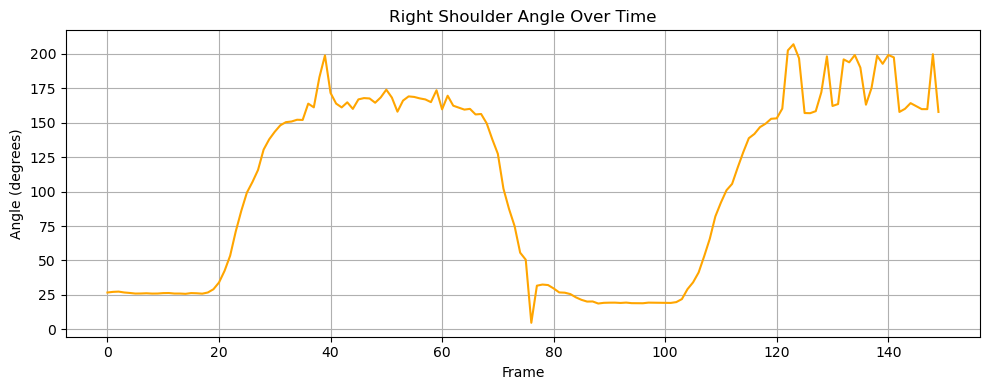

Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\plots\sample_right_shoulder_angle.png


In [45]:
plt.figure(figsize=(10, 4))
plt.plot(sample_shoulder_df["frame"], sample_shoulder_df["shoulder_angle_deg"], color="orange")
plt.title("Right Shoulder Angle Over Time")
plt.xlabel("Frame")
plt.ylabel("Angle (degrees)")
plt.grid(True)
plt.tight_layout()

shoulder_plot_path = PLOTS_DIR / "sample_right_shoulder_angle.png"
plt.savefig(shoulder_plot_path, dpi=150)
plt.show()

print("Saved:", shoulder_plot_path)

## Step 13: Wrist trajectory

The wrist path gives me another view of the movement.

A cleaner arm raise may produce a cleaner path. A poor one may drift or wobble more.

In [46]:
def extract_wrist_trajectory(df, side="right"):
    wrist_id = 16 if side == "right" else 15
    rows = []

    for f in sorted(df["frame"].unique()):
        point = get_landmark_xy(df, f, wrist_id)
        if point:
            rows.append({
                "frame": f,
                "x": point[0],
                "y": point[1]
            })

    return pd.DataFrame(rows)

def compute_path_length(traj_df):
    if len(traj_df) < 2:
        return np.nan

    total = 0.0
    for i in range(1, len(traj_df)):
        dx = traj_df.iloc[i]["x"] - traj_df.iloc[i - 1]["x"]
        dy = traj_df.iloc[i]["y"] - traj_df.iloc[i - 1]["y"]
        total += math.sqrt(dx**2 + dy**2)

    return total

def compute_mean_step_displacement(traj_df):
    if len(traj_df) < 2:
        return np.nan

    distances = []
    for i in range(1, len(traj_df)):
        dx = traj_df.iloc[i]["x"] - traj_df.iloc[i - 1]["x"]
        dy = traj_df.iloc[i]["y"] - traj_df.iloc[i - 1]["y"]
        distances.append(math.sqrt(dx**2 + dy**2))

    return float(np.mean(distances))

sample_wrist_df = extract_wrist_trajectory(sample_df, side="right")

print("Wrist path length:", round(compute_path_length(sample_wrist_df), 2))
print("Mean frame-to-frame wrist displacement:", round(compute_mean_step_displacement(sample_wrist_df), 2))

display(sample_wrist_df.head())

Wrist path length: 4380.32
Mean frame-to-frame wrist displacement: 29.4


,frame,x,y
0,0,472,612
1,1,472,614
2,2,472,615
3,3,472,615
4,4,472,617


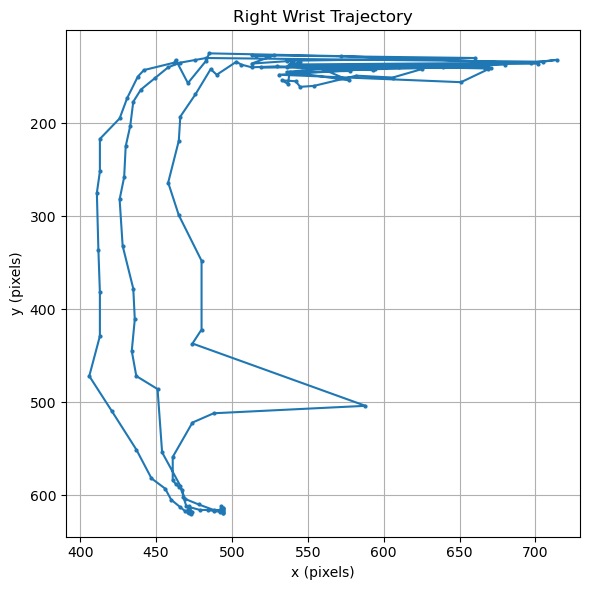

Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\plots\sample_right_wrist_trajectory.png


In [47]:
plt.figure(figsize=(6, 6))
plt.plot(sample_wrist_df["x"], sample_wrist_df["y"], marker="o", markersize=2)
plt.gca().invert_yaxis()
plt.title("Right Wrist Trajectory")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.grid(True)
plt.tight_layout()

traj_plot_path = PLOTS_DIR / "sample_right_wrist_trajectory.png"
plt.savefig(traj_plot_path, dpi=150)
plt.show()

print("Saved:", traj_plot_path)

## Step 14: Simple repetition counting

Arm raise is a repetitive movement.

A good baseline is:
1. compute shoulder angle over time
2. smooth the signal
3. count peaks

In [48]:
def moving_average(signal, window=5):
    if len(signal) < window:
        return signal
    return np.convolve(signal, np.ones(window) / window, mode="same")

def count_repetitions_from_peaks(signal, min_height=None):
    count = 0
    peak_indices = []

    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i - 1] and signal[i] > signal[i + 1]:
            if min_height is None or signal[i] >= min_height:
                count += 1
                peak_indices.append(i)

    return count, peak_indices

smooth_signal = moving_average(sample_shoulder_df["shoulder_angle_deg"].values, window=7)
rep_count, peak_indices = count_repetitions_from_peaks(
    smooth_signal,
    min_height=np.percentile(smooth_signal, 70)
)

print("Estimated repetitions:", rep_count)
print("Peak indices:", peak_indices[:10])

Estimated repetitions: 10
Peak indices: [40, 48, 52, 56, 58, 125, 132, 135, 137, 146]


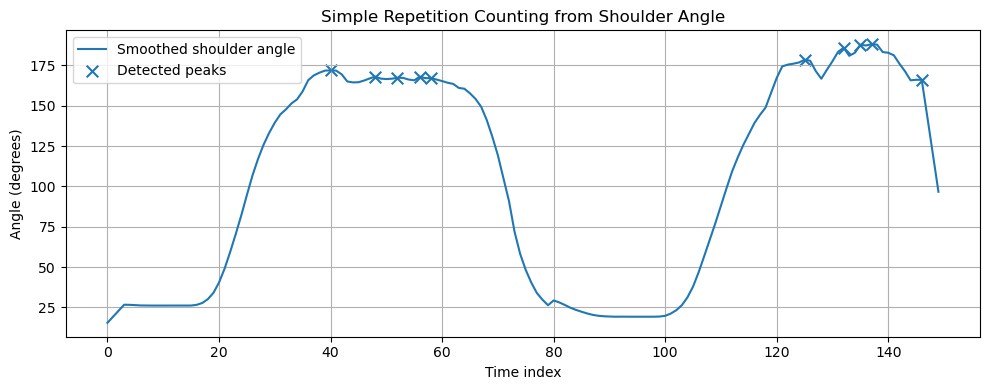

Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\plots\sample_repetition_counting.png


In [49]:
plt.figure(figsize=(10, 4))
plt.plot(smooth_signal, label="Smoothed shoulder angle")
plt.scatter(peak_indices, smooth_signal[peak_indices], marker="x", s=70, label="Detected peaks")
plt.title("Simple Repetition Counting from Shoulder Angle")
plt.xlabel("Time index")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.grid(True)
plt.tight_layout()

rep_plot_path = PLOTS_DIR / "sample_repetition_counting.png"
plt.savefig(rep_plot_path, dpi=150)
plt.show()

print("Saved:", rep_plot_path)

## Step 15: Process all 10 videos

Now I move beyond one sample.

I process:
- 5 correct videos
- 5 incorrect videos

That lets me compare the two groups.

In [50]:
def process_video_with_tasks(video_path, label_name, draw_landmarks=True, max_frames=150):
    cap = cv2.VideoCapture(str(video_path))
    rows = []
    processed_frames = []
    frame_idx = 0

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30.0

    # Create a fresh landmarker for this video only
    base_options = python.BaseOptions(model_asset_path=str(POSE_MODEL_PATH))
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_segmentation_masks=False
    )

    with vision.PoseLandmarker.create_from_options(options) as local_landmarker:
        while True:
            success, frame = cap.read()
            if not success:
                break

            if max_frames is not None and frame_idx >= max_frames:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

            timestamp_ms = int((frame_idx / fps) * 1000)
            result = local_landmarker.detect_for_video(mp_image, timestamp_ms)

            h, w, _ = frame.shape

            if result.pose_landmarks:
                if draw_landmarks:
                    frame = draw_pose_landmarks_tasks(frame, result.pose_landmarks)

                for pose_id, pose_landmarks in enumerate(result.pose_landmarks):
                    for landmark_id, lm in enumerate(pose_landmarks):
                        cx, cy = to_pixel(lm.x, lm.y, w, h)

                        rows.append({
                            "video_name": video_path.name,
                            "label": label_name,
                            "frame": frame_idx,
                            "pose_id": pose_id,
                            "landmark_id": landmark_id,
                            "x_norm": lm.x,
                            "y_norm": lm.y,
                            "z_norm": lm.z,
                            "visibility": getattr(lm, "visibility", np.nan),
                            "x_px": cx,
                            "y_px": cy
                        })

            processed_frames.append(frame.copy())
            frame_idx += 1

    cap.release()
    return pd.DataFrame(rows), processed_frames

## Step 16: Build per-video summary features

For each video, I compute:

- max shoulder angle
- mean shoulder angle
- shoulder angle range
- max elbow angle
- mean elbow angle
- wrist path length
- mean wrist displacement

These are simple, interpretable summary features.

In [52]:
all_video_dfs = []

for video_path in correct_videos:
    df, _ = process_video_with_tasks(
        video_path,
        label_name="correct",
        draw_landmarks=False,
        max_frames=150
    )
    all_video_dfs.append(df)

for video_path in incorrect_videos:
    df, _ = process_video_with_tasks(
        video_path,
        label_name="incorrect",
        draw_landmarks=False,
        max_frames=150
    )
    all_video_dfs.append(df)

all_landmarks_df = pd.concat(all_video_dfs, ignore_index=True)

print("Combined rows:", len(all_landmarks_df))
display(all_landmarks_df.head())

Combined rows: 47058


,video_name,label,frame,pose_id,landmark_id,x_norm,y_norm,z_norm,visibility,x_px,y_px
0,11.mp4,correct,0,0,0,0.476368,0.436418,-0.337285,0.993482,609,314
1,11.mp4,correct,0,0,1,0.482874,0.410415,-0.326228,0.991915,618,295
2,11.mp4,correct,0,0,2,0.487637,0.410492,-0.326277,0.991715,624,295
3,11.mp4,correct,0,0,3,0.492449,0.410439,-0.326535,0.990893,630,295
4,11.mp4,correct,0,0,4,0.469834,0.408648,-0.326051,0.991896,601,294


In [53]:
if "all_landmarks_df" not in globals():
    raise NameError("all_landmarks_df does not exist yet. Run the all-video processing cell first.")

def compute_video_summary(video_df):
    video_name = video_df["video_name"].iloc[0]
    label = video_df["label"].iloc[0]

    shoulder_df = compute_shoulder_angle_series(video_df, side="right")
    elbow_df = compute_elbow_angle_series(video_df, side="right")
    wrist_df = extract_wrist_trajectory(video_df, side="right")

    summary = {
        "video_name": video_name,
        "label": label,
        "max_shoulder_angle": shoulder_df["shoulder_angle_deg"].max() if len(shoulder_df) > 0 else np.nan,
        "mean_shoulder_angle": shoulder_df["shoulder_angle_deg"].mean() if len(shoulder_df) > 0 else np.nan,
        "shoulder_angle_range": (
            shoulder_df["shoulder_angle_deg"].max() - shoulder_df["shoulder_angle_deg"].min()
        ) if len(shoulder_df) > 0 else np.nan,
        "max_elbow_angle": elbow_df["elbow_angle_deg"].max() if len(elbow_df) > 0 else np.nan,
        "mean_elbow_angle": elbow_df["elbow_angle_deg"].mean() if len(elbow_df) > 0 else np.nan,
        "wrist_path_length": compute_path_length(wrist_df),
        "mean_wrist_displacement": compute_mean_step_displacement(wrist_df)
    }

    return summary

video_summaries = []
for video_name in all_landmarks_df["video_name"].unique():
    video_df = all_landmarks_df[all_landmarks_df["video_name"] == video_name]
    video_summaries.append(compute_video_summary(video_df))

summary_df = pd.DataFrame(video_summaries)
display(summary_df)

,video_name,label,max_shoulder_angle,mean_shoulder_angle,shoulder_angle_range,max_elbow_angle,mean_elbow_angle,wrist_path_length,mean_wrist_displacement
0,11.mp4,correct,206.813599,106.047026,202.015573,317.978631,195.039243,4380.320658,29.398125
1,110.mp4,correct,358.788208,247.472847,358.745637,225.323922,201.931699,2936.041746,19.704978
2,111.mp4,correct,357.731612,160.004881,350.496246,359.680835,172.447372,4675.457689,33.396126
3,112.mp4,correct,359.987032,98.937992,357.674499,205.087469,162.132229,3657.764073,25.578770
4,113.mp4,correct,359.723342,137.579597,359.563196,227.205673,199.050014,2962.556131,19.882927
5,01.mp4,incorrect,357.377002,127.489551,356.353972,353.088773,215.836938,5323.078728,35.725361
6,010.mp4,incorrect,359.802614,130.744532,359.577839,257.616574,167.767882,6610.046059,44.362725
7,011.mp4,incorrect,359.946178,166.845978,357.203216,359.512959,209.493533,6503.348432,51.613876
8,012.mp4,incorrect,359.185094,76.233952,357.257069,357.416783,166.749574,5820.984066,48.508201
9,013.mp4,incorrect,357.553021,66.688256,357.430619,300.724693,169.875160,11977.069736,84.345562


In [54]:
summary_csv_path = CSV_DIR / "arm_raise_video_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)
print("Saved:", summary_csv_path)


Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\csv\arm_raise_video_summary.csv


## Step 17: Compare correct vs incorrect arm raise videos

This is the key comparison step.

I want to see whether the extracted movement features differ between:
- correct arm raises
- incorrect arm raises

In [55]:
group_means = summary_df.groupby("label")[[
    "max_shoulder_angle",
    "mean_shoulder_angle",
    "shoulder_angle_range",
    "max_elbow_angle",
    "mean_elbow_angle",
    "wrist_path_length",
    "mean_wrist_displacement"
]].mean()

display(group_means)

,max_shoulder_angle,mean_shoulder_angle,shoulder_angle_range,max_elbow_angle,mean_elbow_angle,wrist_path_length,mean_wrist_displacement
label,,,,,,,
correct,328.608758,150.008469,325.699031,267.055306,186.120111,3722.428060,25.592185
incorrect,358.772782,113.600454,357.564543,325.671956,185.944617,7246.905404,52.911145


C:\Users\nosai\AppData\Local\Temp\ipykernel_31212\3129782091.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([correct_vals.dropna(), incorrect_vals.dropna()], labels=["Correct", "Incorrect"])
C:\Users\nosai\AppData\Local\Temp\ipykernel_31212\3129782091.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([correct_vals.dropna(), incorrect_vals.dropna()], labels=["Correct", "Incorrect"])
C:\Users\nosai\AppData\Local\Temp\ipykernel_31212\3129782091.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([correct_vals.dropna(), incorrect_vals.dropna()], labels=["Correct", "Incorrect"])
C

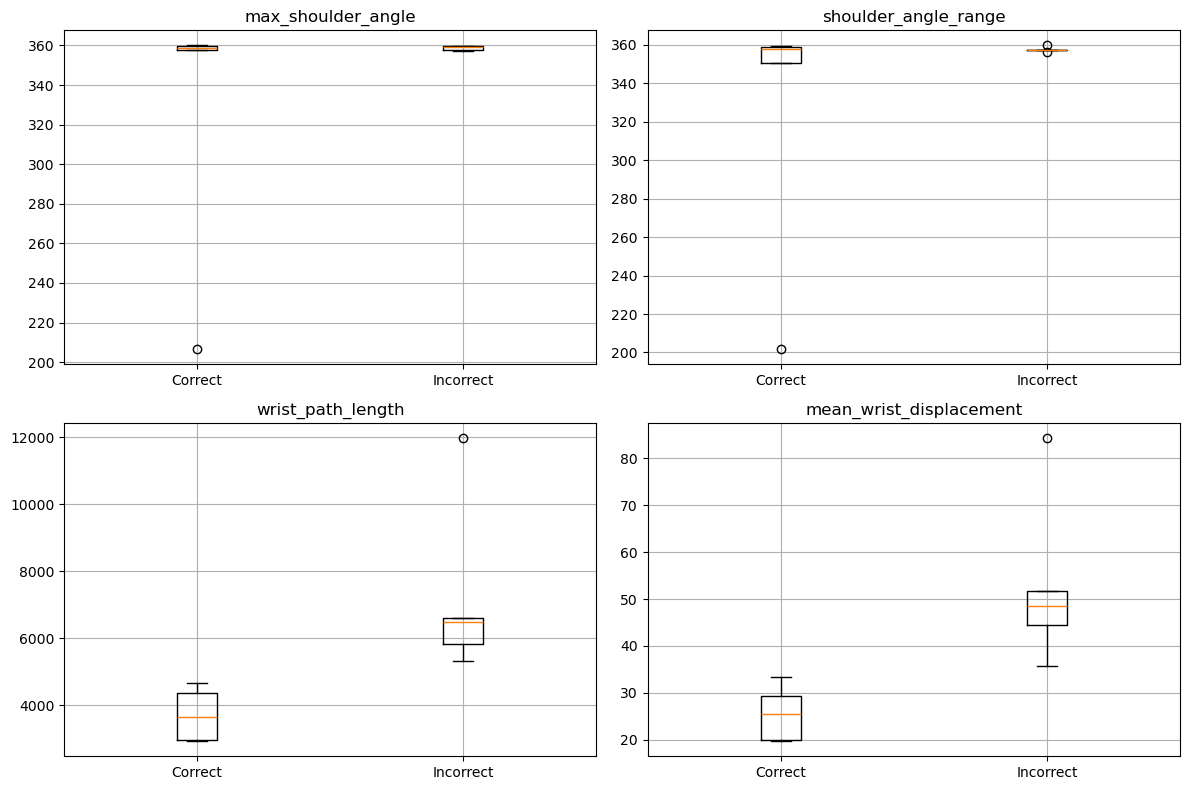

Saved: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\plots\correct_vs_incorrect_comparison.png


In [56]:
metrics_to_plot = [
    "max_shoulder_angle",
    "shoulder_angle_range",
    "wrist_path_length",
    "mean_wrist_displacement"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    correct_vals = summary_df[summary_df["label"] == "correct"][metric]
    incorrect_vals = summary_df[summary_df["label"] == "incorrect"][metric]

    ax.boxplot([correct_vals.dropna(), incorrect_vals.dropna()], labels=["Correct", "Incorrect"])
    ax.set_title(metric)
    ax.grid(True)

plt.tight_layout()

comparison_plot_path = PLOTS_DIR / "correct_vs_incorrect_comparison.png"
plt.savefig(comparison_plot_path, dpi=150)
plt.show()

print("Saved:", comparison_plot_path)

## Step 18: What this means in the context of Prof. Ricca’s lab

I do not see this project as pose estimation for its own sake.

I see it as a behavioural analysis layer for rehabilitation and immersive training systems.

### Why I think it matters
It is about:
- movement learning
- interaction fidelity
- feedback design
- retention
- transfer
- behavioural evaluation

A training system still needs a way to measure what the learner actually did.

This notebook is my first answer to that problem on the vision side.

### What it could support later

If I extended this pipeline, it could support:
- adaptive feedback when the arm raise is incomplete
- tracking whether movement quality improves over repeated sessions
- comparing movement under different immersive conditions
- measuring whether correct and incorrect patterns separate more clearly under certain feedback designs

## Step 19: limitations

I would not present this as a finished clinical tool.

Its limits are real:

- the landmarks are estimates, not clinical ground truth
- this is monocular RGB, so depth is limited
- these angles are simple proxies, not full biomechanical measurements
- blurred videos may reduce landmark quality
- movement quality is richer than a few summary features
- this does not prove transfer or learning outcome by itself

That said, I still think it is a strong first technical step because it turns raw rehab video into measurable behavioural signals.

In [58]:
print("Notebook complete.")
print("Plots saved in:", PLOTS_DIR)
print("Frames saved in:", FRAMES_DIR)
print("CSV files saved in:", CSV_DIR)

Notebook complete.
Plots saved in: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\plots
Frames saved in: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\frames
CSV files saved in: c:\Users\nosai\Downloads\rehab-pose-analysis\outputs\csv
